# 데이터 구조 탐색

In [165]:
import numpy as np
import pandas as pd
from IPython import display

train = pd.read_csv("../data/raw/train.csv").copy()

head()로 구조 확인
* 특성 개수 11개
* 범주형/숫자형/문자열 등을 확인할 수 있음
    * Pclass, Sex, Embarked, Survived
    * Cabin은 범주형인지 잘 모르겠음 -> value_counts()로 확인해봐야 알 수 있을듯
* 레이블은 Survived

In [166]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


info()로 데이터 결측치 유무 확인 및 데이터 타입 확인
* 행 개수는 총 891개 -> 상당히 적음을 알 수 있음
* Age, Cabin, Embarked에 결측치 존재
* 그러나 테스트셋에는 다른 열에도 결측치가 존재할 가능성을 염두에 둬야한다.

In [167]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


각 범주형 특성에 대해 각 범주타입 개수를 확인한다.
* Pclass -> 3,2,1있음
* Sex -> male, female
* Embarked -> S, C, Q있음

In [168]:
from IPython.display import display
categories = ["Pclass", "Sex", "Embarked", "SibSp", "Parch"]
cat_train = train[categories].copy()
for col in categories:
    print(cat_train[col].value_counts())

Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Sex
male      577
female    314
Name: count, dtype: int64
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


In [169]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


* 여기에서 describe로 딱히 알만한건 없음
* 그나마 스케일이 좀 다르다는거? -> 나머지는 히스토그램으로 확인예정
* 특히 AGe, Fare의 평균이 다른 특성에 비해 높다.
* 또한 Fare는 max값을 보면 평균에 비해 상당히 높음 -> 이상치 존재 (이상치는 아니지만 범위가 너무 넓음 근데 75%백분위수를 보면 상당수의 값은 30이하로 되어있음을 알 수 있다.

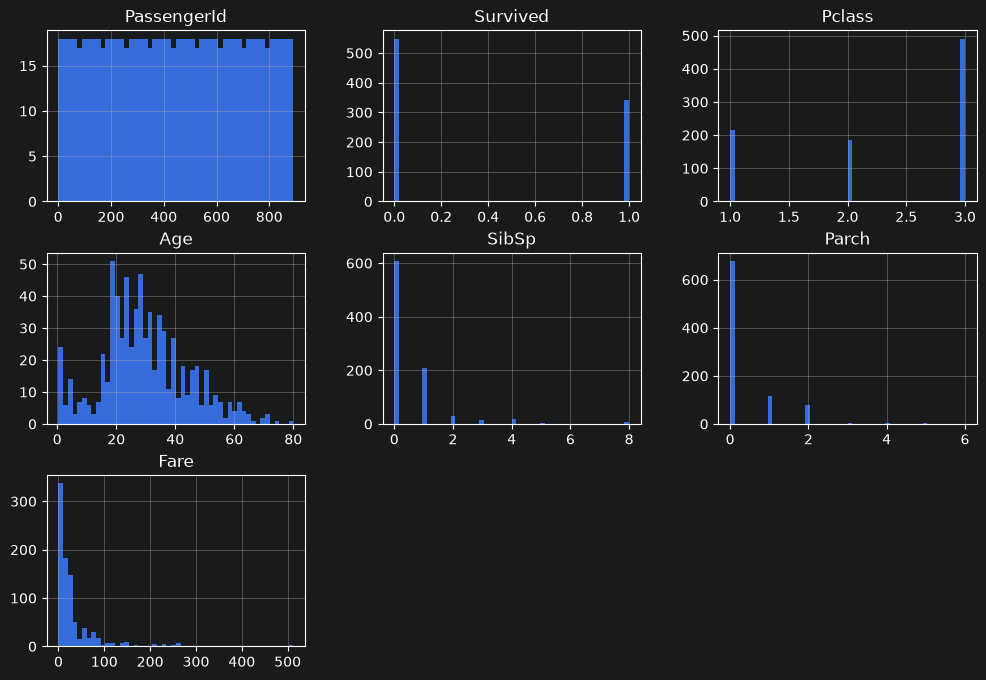

In [170]:
import matplotlib.pyplot as plt
train.hist(bins=50, figsize=(12, 8))
plt.show()

* fare는 오른쪽 꼬리가 상당히 김 (describe에서 확인함)
* Age, Fare의 스케일 조정이 필요 (describe에서 확인함)
* 최댓값, 최솟값이 한정된 특성은 없다.


# 테스트 셋 분리
* test.csv가 존재하지만 이는 실제 제출용 데이터일 뿐 -> 실제 모델에서 사용하는 test셋으로 생각할 필요가 없음
* 어차피 학습 과정에서 k-fold를 사용하기 때문에 -> 검증 세트 자체는 필요가 없음
* 하지만 각 모델별 최종 성능을 측정할 테스트셋을 따로 분리해야 최종 모델을 선택할 수 있음
* 참고로 검증 세트는 하이퍼파라미터를 조정할때 기준점이 된다.
* **계층적 샘플링 적용(Pclass)**

train -> 	모델 파라미터 학습 (fit) (계속 사용)


validation ->   하이퍼파라미터 튜닝, 모델별 비교 (모델을 한번 학습 시킬 때 마다 검증셋을 임시 테스트셋으로 계속 사용)


(검증셋은 우연히 잘못 뽑힐 가능성으로 인해 안정적인 성능 평가를 위해 k-fold사용)


test -> 최종 모델이 결정되면 train + validation으로 전체 재학습 후 -> test셋으로 최종 성능 평가


In [171]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    train, test_size=0.2, stratify=train["Pclass"], random_state=42
)

print(train_set.head())
type(train_set)
train_set.to_csv("../data/processed/01/train.csv", index=False)
test_set.to_csv("../data/processed/01/test.csv", index=False)

# 나눠놓은 학습/테스트 셋 오염방지를 위해 복사하여 이후 시각화
train_set = train_set.copy()
test_set = test_set.copy()


     PassengerId  Survived  Pclass  \
820          821         1       1   
439          440         0       2   
821          822         1       3   
403          404         0       3   
343          344         0       2   

                                                  Name     Sex   Age  SibSp  \
820  Hays, Mrs. Charles Melville (Clara Jennings Gr...  female  52.0      1   
439             Kvillner, Mr. Johan Henrik Johannesson    male  31.0      0   
821                                  Lulic, Mr. Nikola    male  27.0      0   
403                     Hakkarainen, Mr. Pekka Pietari    male  28.0      1   
343         Sedgwick, Mr. Charles Frederick Waddington    male  25.0      0   

     Parch            Ticket     Fare Cabin Embarked  
820      1             12749  93.5000   B69        S  
439      0        C.A. 18723  10.5000   NaN        S  
821      0            315098   8.6625   NaN        S  
403      0  STON/O2. 3101279  15.8500   NaN        S  
343      0           

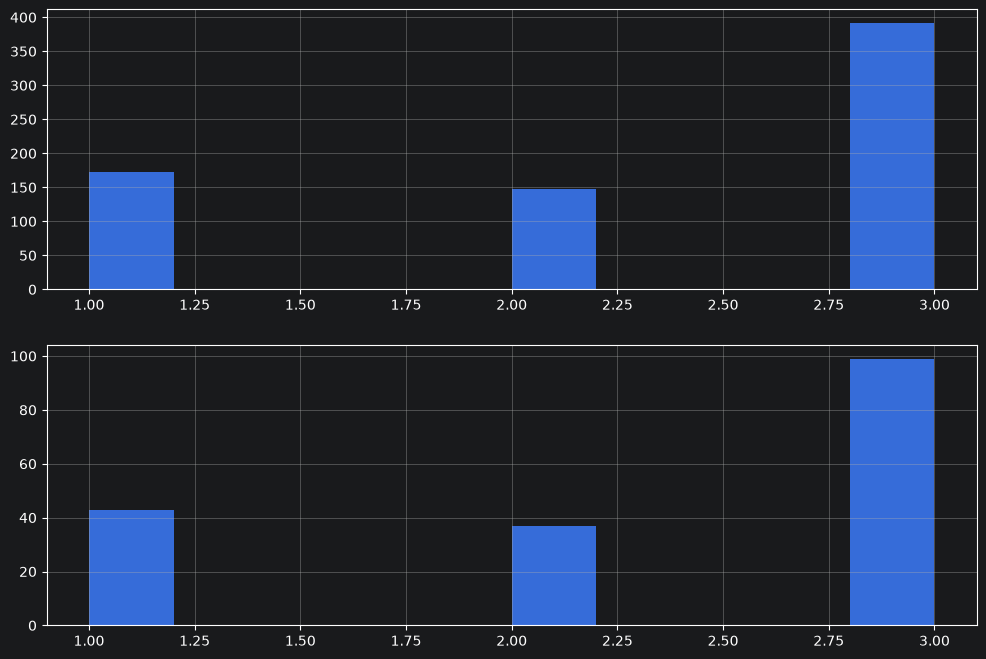

In [172]:
## 잘 분리 됐는지 확인
fig, axes = plt.subplots(nrows=2, figsize=(12, 8))
train_set["Pclass"].hist(ax=axes[0])
test_set["Pclass"].hist(ax=axes[1])
plt.show()

# 데이터 시각화
* 항상 y축에는 타깃이 들어가야한다. 왜? 타깃과의 연관성을 시각화하여 인사이트를 얻기 위해서..
* 타이타닉 문제는 회귀가 아닌 분류 문제이기 때문에 시각화 접근을 다르게 해야함 -> 타깃이 0/1로만 있음 따라서 y축에 타깃을 그대로 넣을 수가 없음
    * 어떻게? 1/0대신에 타깃의 평균을 넣는다.
    * 근데 타깃의 평균을 내기 위해서는 각 범주들의 그룹별로 묶은 뒤 타깃의 평균을 각각 내서 확인해야함
    * 따라서 숫자형 또한 범주형으로 변경하여 타깃의 평균을 확인한다.

정리하자면 분류 EDA는 모든 피처를 그룹으로 만들고, 그룹별 타깃 평균을 막대로 그린다.


* 또한 추가적으로 타깃을 0/1로 그룹화하여 생존자 그룹의 나이 분포/티켓 가격 분포, 비생존자 그룹의 .. 을 확인해야한다.





1. 모든 특성을 범주형으로 변경한다.
2. 그룹별 생존율을 확인해야함
    1. 가장 생존율이 차이가 나는 특성을 우선순위로 시각화한다.
    2. 또한 타깃에 강하게 연관된 특성에 대해 각 조합을 확인한다.
        1. 이때 가장 강하게 연관된 특성 하나를 잡고 나머지 특성에 대해 조합해보는게 빠르고 효율적
3. 범주형 -> 범주별 생존 여부의 수치를 막대그래프로 확인
4. 숫자형 -> 타깃값을 그룹화하여 생존자/비생존자의 숫자형 특성의 분포를 확인하라
5. 타깃과 강하게 연관된 특성끼리의 조합을 시각화하여 더 깊게 탐색

### 1. 숫자형에 대해 범주형 특성 새로 생성

In [173]:
train_set["cat_age"] = pd.cut(train_set["Age"], bins=[0,10, 15,20,30,40,60,80,100])
train_set["cat_fare"] = pd.qcut(train_set["Fare"], q=4)

### 2. 그룹별 생존율 확인

In [174]:
categories = ["Pclass", "Sex", "Embarked", "SibSp", "Parch", "cat_age", "cat_fare"]
for col in categories:
    print(train_set.groupby(col)["Survived"].mean().sort_values(ascending=False))

Pclass
1    0.647399
2    0.455782
3    0.257653
Name: Survived, dtype: float64
Sex
female    0.764000
male      0.192641
Name: Survived, dtype: float64
Embarked
C    0.544828
Q    0.419355
S    0.343936
Name: Survived, dtype: float64
SibSp
1    0.518293
2    0.434783
0    0.369072
3    0.266667
4    0.117647
5    0.000000
8    0.000000
Name: Survived, dtype: float64
Parch
1    0.541667
2    0.530303
0    0.356215
3    0.333333
4    0.000000
5    0.000000
6    0.000000
Name: Survived, dtype: float64
cat_age
(10, 15]    0.588235
(0, 10]     0.584906
(30, 40]    0.457364
(40, 60]    0.404255
(20, 30]    0.365591
(15, 20]    0.363636
(60, 80]    0.277778
Name: Survived, dtype: float64
cat_fare
(31.275, 512.329]    0.594286
(14.454, 31.275]     0.426136
(7.896, 14.454]      0.350000
(-0.001, 7.896]      0.209945
Name: Survived, dtype: float64


* Embarked 특성은 크게 타깃에 연관이 없는 듯 하다
* SibSp, Parch는 연관이 있어보이나 생존율이 낮은 범주들은 모두 개체 개수 자체가 적기 때문에 학습셋에 과대적합될 가능성이 존재한다. -> 나중에 특성을 가공하여 생존율과의 연관을 확인 후 사용
* 의외로 age, fare를 범주화한 특성이 생존율에 강한 연관을 가지는 듯 하다
    * age특성에서는 의외로 15\~20살, 20\~30대의 나이대가 생존율이 낮은 경향을 보이기 때문
        * 아마 구출 과정에서 젊은 나이대가 구출을 돕는 경향이 높아서? 인듯
        * 나중에 성별과 엮어서 확인해보면 더 좋은 연관을 얻을 수 있을 것 같다.
    * fare 특성은 직관 그대로 티켓 가격이 높을수록 생존율이 높은 관계를 확인할 수 있음

### 3. 범주형 특성별 생존율 시각화
-> 위의 그룹별 생존율 표로도 확인이 가능하지만 그냥 나중에 다시 봐도 헷갈리지 않게 하려고..

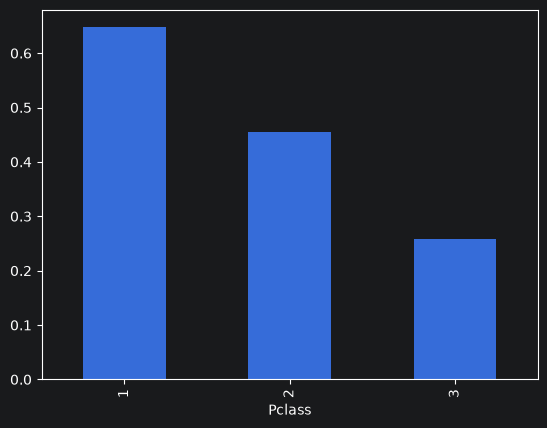

In [175]:
train_set.groupby("Pclass")["Survived"].mean().plot(kind="bar")
plt.show()

<Axes: xlabel='Sex'>

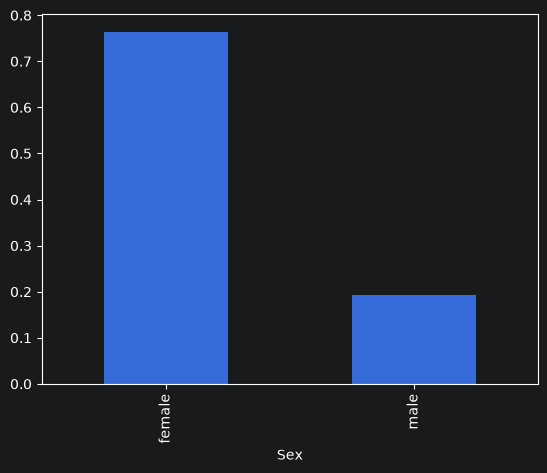

In [176]:
train_set.groupby("Sex")["Survived"].mean().plot(kind="bar")

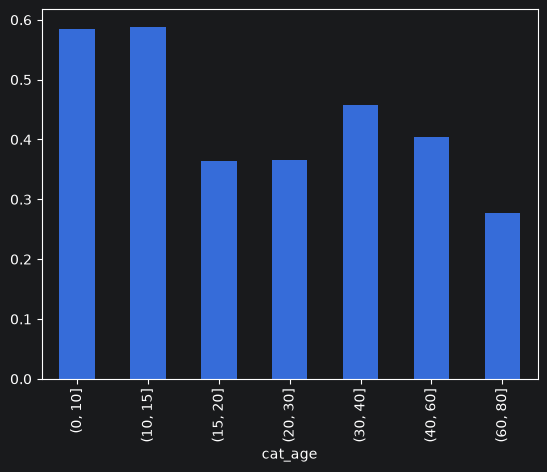

In [177]:
train_set.groupby("cat_age")["Survived"].mean().plot(kind="bar")
plt.show()

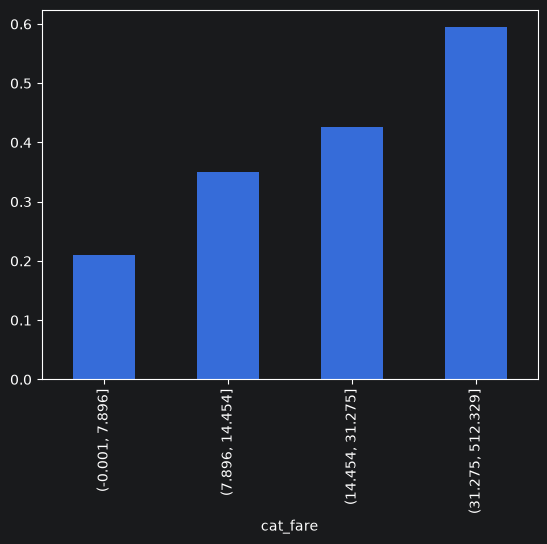

In [178]:
train_set.groupby("cat_fare")["Survived"].mean().plot(kind="bar")
plt.show()

### 4. 가장 강하게 연관된 특성에 대해 모든 조합의 생존율 확인하기
* 컬럼 Sex사용
* dataframe클래스 함수중 pivot_table함수 사용
    * index -> 세로축에 둘 컬럼을 지정한다.
    * columns -> 가로축에 둘 컬럼을 지정한다.
        *  -> index + columns 조합으로 그룹화가 된다.
        * 다시 말해 index컬럼별로 먼저 그룹화가 되고 각 그룹내에서도 columns별로 그룹화가 되어 지정한 value의 값이 나옴
        * value -> 그룹화된 값들의 조회할 값 지정 (기본 값 계산방법은 평균을 구하기 때문에 Survived행을 지정하면 각 그룹의 Survived컬럼의 평균값이 나온다고 생각하면 된다.)


* 또한 각 조합의 그룹별로 개체의 개수도 확인해야한다. 왜? -> 여성 + 80세의 생존율이 0.98로 나와도 해당 그룹의 개체 개수가 3명이라면??
    * 30명 미만 → 참고만, 결론 내리지 말 것
    * 10명 미만 → 무시
    * 100명 이상 → 안정적

1. Sex + Pclass 조합
    * 1등석, 2등석 + 여성은 가장 생존율이 높음
    * 3등석부터 여성은 급격하게 생존율이 낮아짐
    * 전체적으로 남성보다 여성이 생존율이 상당히 높은 모습


특성 조합에 따라 생존율이 높아지는 특정 조합을 발견할 수 없음. 단순히 성별과 좌석 등급의 추이를 따라가는 모습이다.

-> 등급이 낮아질 수록 생존율이 떨어지는 모습

-> 또한 성별의 차이에 따라 전체적인 생존율 차이가 크게 남

mean            count     
Sex       female      male female male
Pclass                                
1       0.962025  0.382979     79   94
2       0.931034  0.146067     58   89
3       0.539823  0.143369    113  279

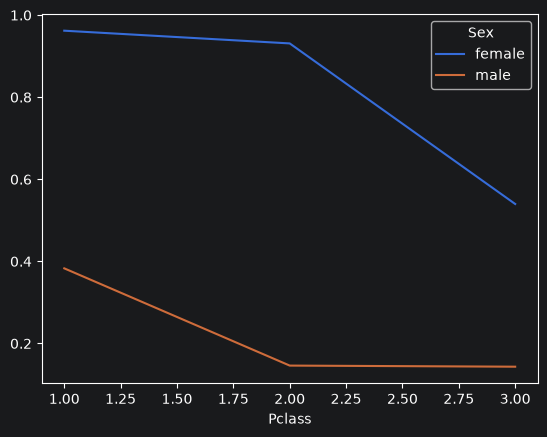

In [179]:
table = train_set.pivot_table(index="Pclass", columns="Sex", values="Survived" ,aggfunc=["mean", "count"])
display(table)

table["mean"].plot(kind="line")
plt.show()

###계속 헷갈리는데 각 컬럼별로 그래프 하나가 생기는 것
###그리고 각 값들이 y축이 되고 행 하나가 x축 하나라고 생각하면 된다.

2. Sex + cat_age조합
* 전체적인 성별에 따른 생존율 차이는 동일하나 나이가 높아질 수록 성별에 따라 생존율 추이가 다르다 -> 주목할만한 지점
* 그러나 각 그룹의 사람 수가 적기 때문에 단순 성인 vs 아이로 나눠도 될 것 같다.

mean            count     
Sex         female      male female male
cat_age                                 
(0, 10]   0.608696  0.566667     23   30
(10, 15]  0.800000  0.285714     10    7
(15, 20]  0.740741  0.160000     27   50
(20, 30]  0.784615  0.140496     65  121
(30, 40]  0.829787  0.243902     47   82
(40, 60]  0.812500  0.193548     32   62
(60, 80]  1.000000  0.133333      3   15

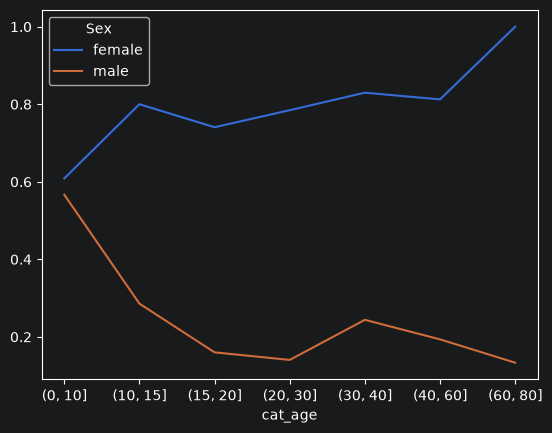

In [180]:
table = train_set.pivot_table(index="cat_age", columns="Sex", values="Survived", aggfunc=["mean", "count"])
display(table)

table["mean"].plot(kind="line")
plt.show()

2번 조합에 대한 추가적인 조사

-> 나이의 범위 자체를 더 넓게 잡았더니 생존율의 큰 차이가 보이지 않는다. 오히려 성별에 따른 생존율 차이만 더 돋보인다.. 뭐지

mean            count     
Sex          female      male female male
isAdult                                  
(0, 20]    0.700000  0.310345     60   87
(20, 40]   0.803571  0.182266    112  203
(40, 100]  0.828571  0.181818     35   77

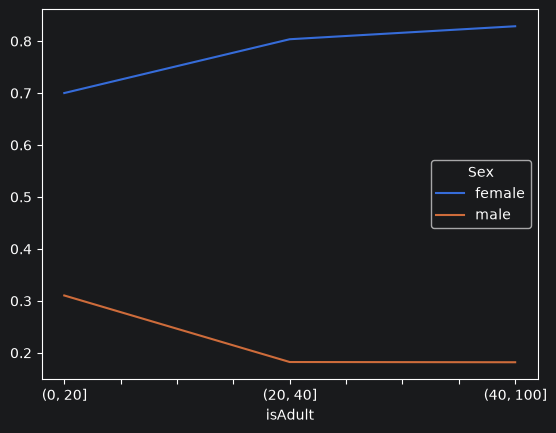

In [181]:
train_set["isAdult"] = pd.cut(train_set["Age"], bins=[0,20, 40, 100])
table = train_set.pivot_table(index="isAdult", columns="Sex", values="Survived" ,aggfunc=["mean", "count"])
display(table)
table["mean"].plot(kind="line")
plt.show()



3. Sex + cat_fare 조합
* 신기하게 여성은 특정 티켓 가격까지는 생존율의 큰 차이를 보이지 않지만 특정 구간 이상부터 생존율이 높음
    * 티켓 가격 구간을 더 잘게 잘라서 추이를 확인해봐야겠다
        * 아 근데 이러면 그룹 별 개체 수가 적어져서 생존율 값의 의미가 없어짐
* 남성 그룹은 단순히 티켓가격이 높아질 수록 생존율이 올라가는 모습
* 또한 알 수 있는 점은 여성은 티켓가격이 높아질 수록 인원수가 많아지고, 남성은 티켓 가격이 낮아질 수록 많아지는 경향을 확인할 수 있음

mean            count     
Sex                  female      male female male
cat_fare                                         
(-0.001, 7.896]    0.771429  0.075342     35  146
(7.896, 14.454]    0.696429  0.193548     56  124
(14.454, 31.275]   0.666667  0.259615     72  104
(31.275, 512.329]  0.885057  0.306818     87   88

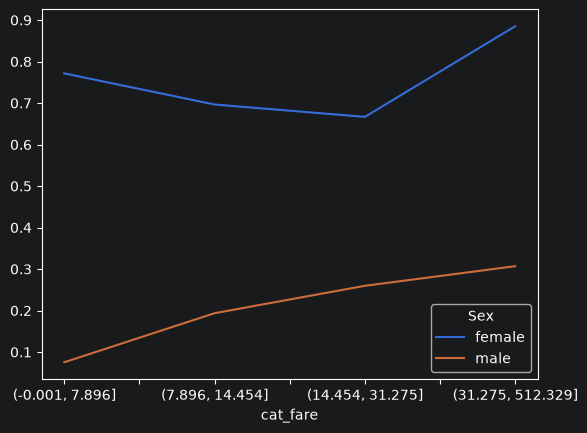

In [182]:
table = train_set.pivot_table(index="cat_fare", columns="Sex", values="Survived", aggfunc=["mean", "count"])
display(table)

table["mean"].plot(kind="line")
plt.show()

### 5. 생존자 그룹에 대해 숫자형 특성 시각화하기
-> 생존자 그룹에 대해 나이의 분포를 확인한다. (비생존자도 동일하게)


-> 생존자 그룹에 대해 가격의 분포를 확인한다.

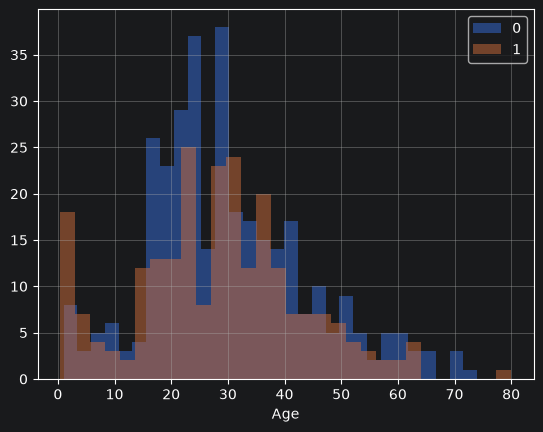

In [183]:
train_set.groupby("Survived")["Age"].hist(bins=30, alpha=0.5, legend=True)
plt.xlabel("Age")
plt.show()

* 비생존자/생존자 그룹의 나이 분포대로 비슷한 경향을 보이나 어린이의 생존율이 상당히 높은 점은 주목할만함
*

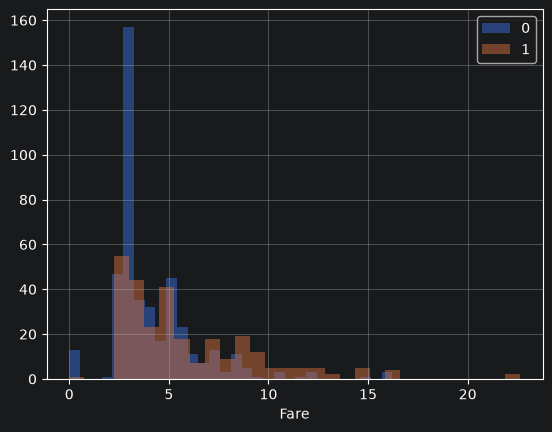

In [184]:
train_set["sqrt(fare)"] = train_set["Fare"].apply(np.sqrt)
train_set.groupby("Survived")["sqrt(fare)"].hist(bins=30, alpha=0.5, legend=True)
plt.xlabel("Fare")
plt.show()

* Fare의 스케일처리를 위해 모든 값에 sqrt함수를 적용후 생존자/비생존자 그룹으로 나누어 분포 확인
* 특정 가격대의 비생존자가 급격히 높은걸 확인할 수 있음
* 가격대가 높을 수록 생존자가 비생존자보다 많이 분포함을 알 수 있다. (오른쪽 꼬리가 길다)
* Pclass의 분포와 동일하므로 나중에 특성은 하나만 사용해도 될 듯? 이상치는 없고 Pclass의 추이를 따라가니까..

### 6. 번외로 "SibSp", "Parch" 특성 조사하기

* SibSp -> 형재 자매와 배우자의 수 (본인 기준)
* Parch -> 부모 + 자식의 수 (본인 기준)

### 사용할 만한 가설
* 가족의 수로 합쳐서 어떤 추이를 확인할 수 있지 않을까?
* cat_age와 Parch의 조합으로 어린이 + 부모가 있으면 어린이는 생존율이 높아지는 경향을 확인할 수 있지 않을까?

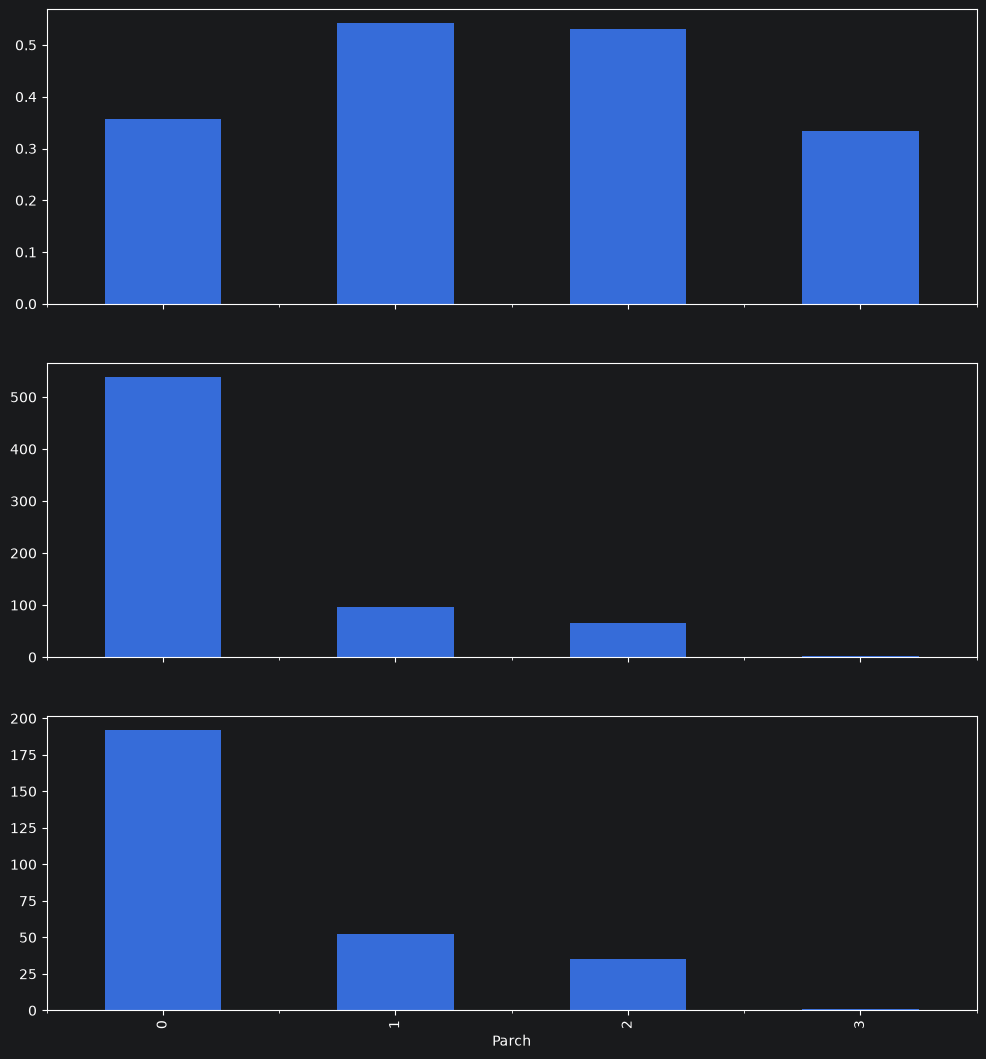

In [216]:
fig, ax = plt.subplots(nrows=3, sharex=True, figsize=(12, 13))


# 생존율
train_set.groupby("Parch")["Survived"].mean().plot(kind="bar", ax=ax[0])

# 전체 숫자별 승객 수
train_set["Parch"].value_counts().sort_index().plot(kind="bar", ax=ax[1])

# 생존자 수
train_set.loc[train_set["Survived"]==1, "Parch"].value_counts().sort_index().plot(kind="bar", ax=ax[2])
plt.show()

* 나이와 조합해야 더 자세하게 확인할 수 있을 것 같음
* 사람 수까지 확인했는데 잘 모르겠음 ..

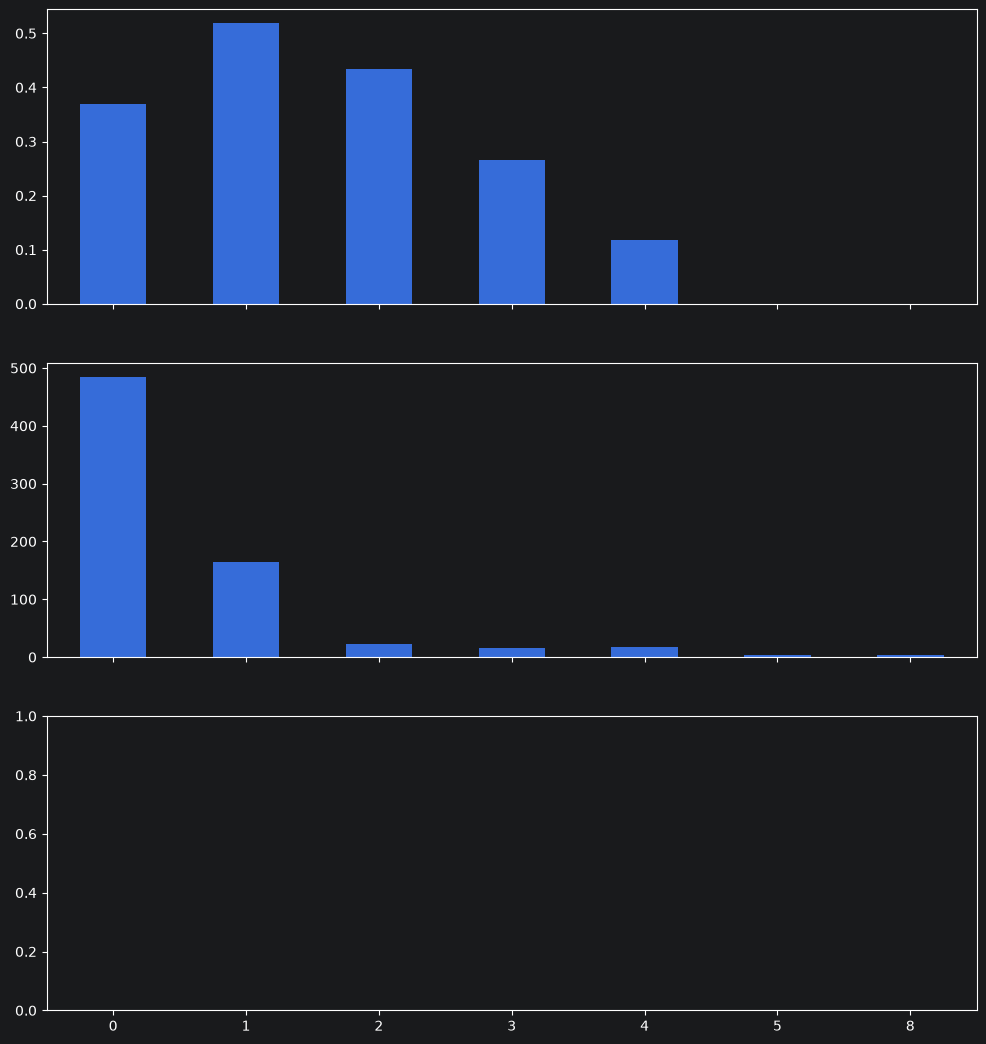

In [218]:
fig, ax = plt.subplots(nrows=3, sharex=True, figsize=(12, 13))


# 생존율
train_set.groupby("SibSp")["Survived"].mean().plot(kind="bar", ax=ax[0])

# 그룹별 승객 수
train_set["SibSp"].value_counts().sort_index().plot(kind="bar", ax=ax[1])

# 생존자 수
# train_set.loc[train_set["Survived"]==1, "Parch"].value_counts().sort_index().plot(kind="bar", ax=ax[2])
plt.show()

* 형재 자매와 배우자 수가 늘어날 수록